<a href="https://colab.research.google.com/github/Bamboohoccode/LLMs_From_Scratch/blob/main/Word2Vec_And_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import numpy as np
import pandas as pd
import torch

In [46]:
!pip install gensim
!pip install nltk

In [47]:
from gensim.models import Word2Vec
import gensim
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk
nltk.download('punkt_tab')
import warnings
warnings.filterwarnings(action='ignore')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [48]:
import zipfile

with zipfile.ZipFile("/content/Gutenburg.zip", 'r') as zip_ref:
    file_name = zip_ref.namelist()[0]
    with zip_ref.open(file_name) as file:
        content = file.read().decode('utf-8', errors='ignore')
        cleaned_text = content.replace("\n", " ")
        print("File loaded")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Gutenburg.zip'

In [49]:
data = []
for i in sent_tokenize(cleaned_text):
    temp = []
    for j in word_tokenize(i):
        temp.append(j.lower())
    data.append(temp)
len(data)


NameError: name 'cleaned_text' is not defined

In [ ]:
print(data[0][:10])

- Vector_size: the number of dimension of vector
- window: [check it out for more detail !!!](https://gemini.google.com/share/39efa683bc4b)

In [ ]:
#CBOW: Context -> Cur word
model1 = gensim.models.Word2Vec(data,min_count = 1,
                                vector_size = 100,window = 5)
#Skip-gram: Cur word -> Context
model2 = gensim.models.Word2Vec(data,min_count = 1,vector_size = 100,
                                window = 5,sg = 1)

Độ liên quan sẽ dùng Cosin similarity giống công thức cosin giũa 2 vector nên sẽ có range từ -1 đến 1

In [ ]:
print(f"Lien quan: {model1.wv.similarity('the','project').item()}")
print(f"Lien quan: {model2.wv.similarity('the','project').item()}")

# From Scratch

In [50]:

raw_text = "The quick brown fox jumps over the lazy dog."
tokens = raw_text.split()
context_size = 2
vocab = set(tokens)
word_to_index = {word: i for i, word in enumerate(vocab)}
data = []
word_to_index
text_length = len(tokens)

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
for i in range(context_size,text_length-1):
    inputs = [word_to_index[word] for word in tokens[i-2:i-1] + tokens[i+1:i+2]] #window_size = 2.
    output = word_to_index[tokens[i]]
    data.append((torch.tensor(inputs),torch.tensor(output)))
data

[(tensor([3, 6]), tensor(1)),
 (tensor([4, 7]), tensor(6)),
 (tensor([1, 0]), tensor(7)),
 (tensor([6, 8]), tensor(0)),
 (tensor([7, 2]), tensor(8)),
 (tensor([0, 5]), tensor(2))]

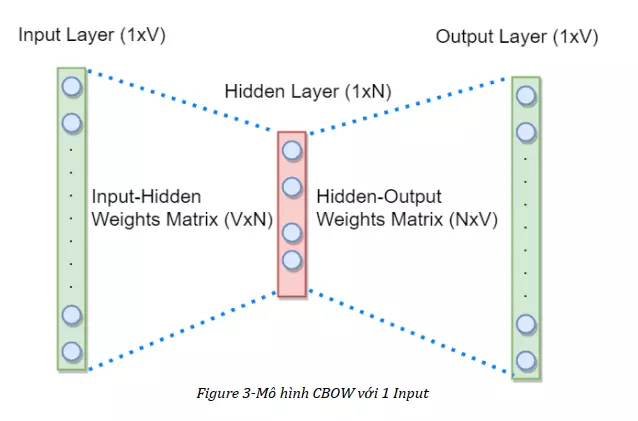

In [52]:
class CBOW(nn.Module):
    def __init__(self,emb_size,num_size):
        super().__init__()
        self.embed_layer = nn.Embedding(num_size,emb_size)
        self.output = nn.Linear(emb_size,num_size) # This's for learning pattern.
    def forward(self,x):
        x = self.embed_layer(x).sum(dim = 0)
        x = self.output(x) # Trả về dạng (num_size) là số chữ.
        return x


In [53]:
len(vocab)

9

The total_loss for each epoch is approximately zeros cuz this's ez for learning the pattern with short sentence.

In [54]:
lr = 0.01
epochs = 100
emb_size = 500
num_size = len(vocab)
model = CBOW(emb_size,num_size)

LOSS = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr)




for epoch in range(epochs):
    total_loss = 0
    for input,output in data:
        torch.no_grad()
        pred = model(input)

        loss = LOSS(pred,output)
        total_loss += loss

        loss.backward()
        optimizer.step()

    if(epoch % 10 == 9):
        print(f"Epoch {epoch + 1}, Loss: {total_loss}")





Epoch 10, Loss: 0.0
Epoch 20, Loss: 0.0
Epoch 30, Loss: 0.0
Epoch 40, Loss: 0.0
Epoch 50, Loss: 0.0
Epoch 60, Loss: 0.0
Epoch 70, Loss: 0.0
Epoch 80, Loss: 0.00014518637908622622
Epoch 90, Loss: 0.0
Epoch 100, Loss: 0.0


In [55]:
a = [[1,2],
     [3,4]]
b = torch.tensor(a)
b.sum(dim = 0)

tensor([4, 6])

# Build the class on my own !


In [60]:
class W2V_CBOW(nn.Module):
    def __init__(self,vector_size,emb_size,window_size,lr = 0.01,epochs = 100,momentum = 0.9):
        super().__init__()
        self.vector_size = vector_size
        self.emb_size = emb_size
        self.window_size = window_size
        self.lr = lr
        self.epochs = epochs
        self.momentum = momentum
        # self.word_to_index = {}
    def forward(self,X):
        tokens = X.split() #At here we can update later.
        vocab= set(tokens)
        vocab_size = len(vocab)
        context_length = len(tokens)
        word_to_index = {word : index for index,word in enumerate(list(vocab))} # We can update this for multiple times training.

        # Prepare data
        data = []
        for i in range(self.window_size,context_length - self.window_size):
            input = [word_to_index[word] for word in tokens[i-self.window_size:i] + tokens[i:i+self.window_size]]
            output = word_to_index[tokens[i]]
            data.append((torch.tensor(input),torch.tensor(output)))
        LOSS = nn.CrossEntropyLoss()
        model = CBOW(self.vector_size,self.emb_size)
        optimizer = optim.SGD(model.parameters(),lr = self.lr,momentum = self.momentum)

        for epoch in range(self.epochs):
            total_loss = 0
            for input,output in data:
                optimizer.zero_grad()
                pred = model(input)
                loss = LOSS(pred,output)
                total_loss += loss
                loss.backward()
                optimizer.step()
            if(epoch%10 == 9):
                print(f"Epoch {epoch + 1} and Loss :{total_loss} ")


In [ ]:
#This version is cleaner than my own,generated by Gemini =) !
class W2V_CBOW_Trainer:
    def __init__(self, vocab_size, emb_size, window_size, lr=0.01, epochs=100):
        self.window_size = window_size
        self.epochs = epochs
        self.model = CBOW(vocab_size, emb_size)
        self.optimizer = optim.SGD(self.model.parameters(), lr=lr, momentum=0.9)
        self.loss_fn = nn.CrossEntropyLoss()

    def train(self, tokens, word_to_index):
        data = []
        # Corrected slicing to include all context words
        for i in range(self.window_size, len(tokens) - self.window_size):
            context = (
                tokens[i - self.window_size : i] +
                tokens[i + 1 : i + self.window_size + 1]
            )
            target = tokens[i]
            input_ids = torch.tensor([word_to_index[w] for w in context], dtype=torch.long)
            target_id = torch.tensor([word_to_index[target]], dtype=torch.long)
            data.append((input_ids, target_id))

        for epoch in range(self.epochs):
            total_loss = 0
            for inputs, target in data:
                self.optimizer.zero_grad() # Crucial: clear old gradients

                log_probs = self.model(inputs)
                loss = self.loss_fn(log_probs, target)

                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()

            if epoch % 10 == 9:
                print(f"Epoch {epoch + 1} | Loss: {total_loss:.4f}")

In [61]:
w2v = W2V_CBOW(100,50,2)
w2v(raw_text)

Epoch 10 and Loss :0.005987087264657021 
Epoch 20 and Loss :0.002393359551206231 
Epoch 30 and Loss :0.0017947870073840022 
Epoch 40 and Loss :0.001489295857027173 
Epoch 50 and Loss :0.0012835112866014242 
Epoch 60 and Loss :0.001131696393713355 
Epoch 70 and Loss :0.001014195499010384 
Epoch 80 and Loss :0.0009204064263030887 
Epoch 90 and Loss :0.0008438953664153814 
Epoch 100 and Loss :0.0007797770667821169 
